# Explore here

In [19]:
import os
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv

# load the .env file variables
load_dotenv()

# Get credential values
client_id = os.environ.get("CLIENT_ID")
client_secret = os.environ.get("CLIENT_SECRET")

In [20]:
import os
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials


auth_manager = SpotifyClientCredentials(client_id=client_id, client_secret=client_secret)
spotify = spotipy.Spotify(auth_manager=auth_manager)

lz_uri = 'spotify:artist:1GImnM7WYVp95431ypofy9'
results = spotify.artist_top_tracks(lz_uri)

for track in results['tracks'][:10]:
    print('track    :', track['name'])
    print('year    :', track['album']['release_date'][:4])
    print('audio    :', track['preview_url'])
    print('cover art:', track['album']['images'][0]['url'])
    print()

track    : Viento
year    : 1988
audio    : None
cover art: https://i.scdn.co/image/ab67616d0000b27352842eb76a050aa8daec1251

track    : Afuera
year    : 1994
audio    : None
cover art: https://i.scdn.co/image/ab67616d0000b27336aeaab4dc91a8dea53a2d8f

track    : La Célula Que Explota
year    : 1990
audio    : None
cover art: https://i.scdn.co/image/ab67616d0000b273a2ada1807eb576d7ad43b721

track    : No Dejes Que...
year    : 1992
audio    : None
cover art: https://i.scdn.co/image/ab67616d0000b273bc4d989c48ad5b154fb0781d

track    : Aquí No Es Así
year    : 1994
audio    : None
cover art: https://i.scdn.co/image/ab67616d0000b27336aeaab4dc91a8dea53a2d8f

track    : Los Dioses Ocultos
year    : 1990
audio    : None
cover art: https://i.scdn.co/image/ab67616d0000b273a2ada1807eb576d7ad43b721

track    : Mátenme Porque Me Muero
year    : 1988
audio    : None
cover art: https://i.scdn.co/image/ab67616d0000b27352842eb76a050aa8daec1251

track    : Nubes
year    : 1992
audio    : None
cover art

In [21]:
tracks_data = []
for track in results['tracks'][:10]:
    nombre = track['name']
    popularidad = track['popularity']
    duracion_min = round(track['duration_ms'] / 60000, 2)
    fecha_lanzamiento = track['album']['release_date'][:4]
    tracks_data.append([nombre, popularidad, duracion_min, fecha_lanzamiento])

# Crear DataFrame
df = pd.DataFrame(tracks_data, columns=["Canción", "Popularidad", "Duración (min)", "Fecha Lanzamiento"])

# Imprimir tabla
print(df)

                                        Canción  Popularidad  Duración (min) Fecha Lanzamiento
0                                        Viento           78            3.94              1988
1                                        Afuera           77            4.81              1994
2                         La Célula Que Explota           77            3.60              1990
3                               No Dejes Que...           77            4.65              1992
4                                Aquí No Es Así           70            4.90              1994
5                            Los Dioses Ocultos           70            4.70              1990
6                       Mátenme Porque Me Muero           70            3.56              1988
7                                         Nubes           69            4.57              1992
8  La Negra Tomasa - Bilongo - Versión Tropical           67            7.87              1988
9                             Debajo de Tu Piel   

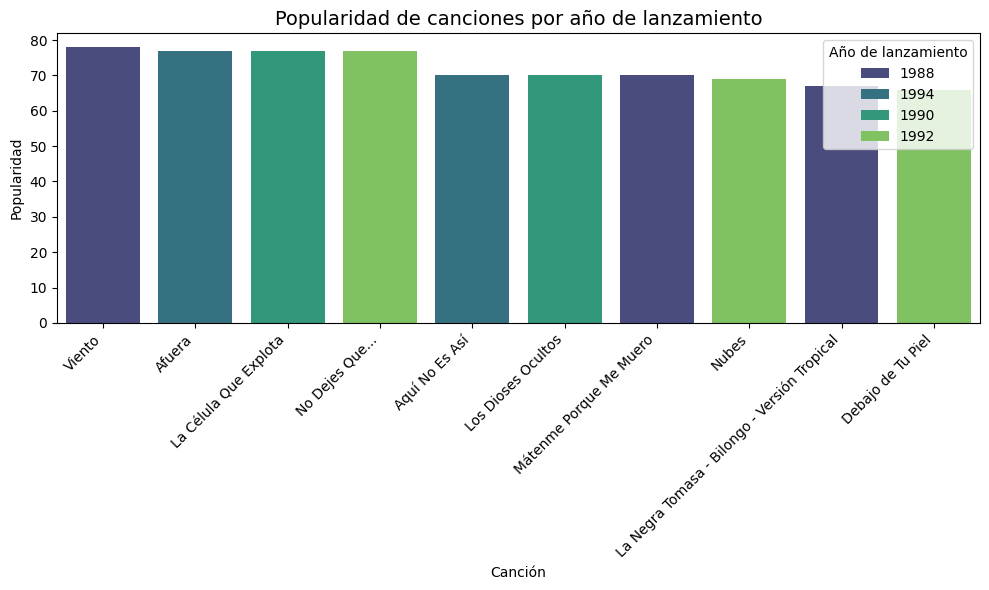

In [22]:
import matplotlib.pyplot as plt

df_sorted = df.sort_values(by="Popularidad", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=df_sorted, x="Canción", y="Popularidad", hue="Fecha Lanzamiento", dodge=False, palette="viridis")

plt.title("Popularidad de canciones por año de lanzamiento", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Popularidad")
plt.xlabel("Canción")
plt.legend(title="Año de lanzamiento")
plt.tight_layout()
plt.show()

